In [4]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [5]:
def create_melspectrogram(df, segmented_dir, all_categories, n_mels=128):
    segmented_dir = Path(segmented_dir)
    melspectrogram_list = []
    labels = []

    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, sr = librosa.load(file, sr=None)
            melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                      sr=sr, 
                                                      n_mels=n_mels, 
                                                      fmax=sr/2)
            melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
            melspectrogram_list.append(melspectrogram_db)
            labels.append(f.label)
            
    X = np.array(melspectrogram_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [6]:
train_csv_path = 'kaggle_meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

In [7]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [8]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('kaggle_data', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

Import data for model

In [9]:
X, y = create_melspectrogram(train_df, 'kaggle_segmented', musical_instruments)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

1847it [01:34, 19.44it/s]


Plot mel spectrogram

In [10]:
def plot_melspectrogram(X, i):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

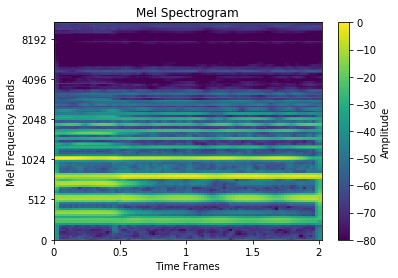

In [11]:
plot_melspectrogram(X_train, 36)

CNN model

In [12]:
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(musical_instruments), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 128, 87, 32)       320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 64, 44, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 64, 44, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 44, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 32, 22, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 32, 22, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 22, 128)       7

Train CNN

In [13]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
150/150 [==============================] - 28s 186ms/step - loss: 2.9307 - accuracy: 0.1718 - val_loss: 2.2853 - val_accuracy: 0.2502
Epoch 2/100
150/150 [==============================] - 27s 178ms/step - loss: 2.2524 - accuracy: 0.2527 - val_loss: 2.1306 - val_accuracy: 0.3169
Epoch 3/100
150/150 [==============================] - 26s 174ms/step - loss: 2.0622 - accuracy: 0.3094 - val_loss: 2.0138 - val_accuracy: 0.3711
Epoch 4/100
150/150 [==============================] - 26s 171ms/step - loss: 1.8731 - accuracy: 0.3697 - val_loss: 1.6257 - val_accuracy: 0.4962
Epoch 5/100
150/150 [==============================] - 25s 166ms/step - loss: 1.7054 - accuracy: 0.4322 - val_loss: 1.7134 - val_accuracy: 0.4837
Epoch 6/100
150/150 [==============================] - 25s 167ms/step - loss: 1.5807 - accuracy: 0.4835 - val_loss: 1.3738 - val_accuracy: 0.6214
Epoch 7/100
150/150 [==============================] - 26s 170ms/step - loss: 1.4005 - accuracy: 0.5384 - val_loss: 1.2709 -

KeyboardInterrupt: 

Evaluate CNN

In [14]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_melspectrogram_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .80

Accuracy: 0.904603068712475

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.88      0.99      0.93        98
       Bass_drum       0.82      0.93      0.87        15
           Cello       0.95      0.95      0.95        21
        Clarinet       0.73      0.81      0.77        37
         Cowbell       0.90      0.87      0.89        63
     Double_bass       0.99      0.88      0.93        92
  Electric_piano       0.95      0.87      0.91       322
           Flute       0.83      0.99      0.91       167
    Glockenspiel       0.91      0.91      0.91       151
       Harmonica       1.00      0.96      0.98        28
          Hi-hat       0.88      0.80      0.84        70
            Oboe       0.97      0.88      0.92        95
       Saxophone       0.94      1.00      0.97        15
      Tambourine       1.00      1.00      1.00        21
         Trumpet       0.94      0.79      0.86       107
Violin_or_fiddle  

Save CNN

In [ ]:
# cnn.save('cnn_melspectrogram_model.h5')